In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0. Cargar Datos

In [2]:
# Cargar datos
columnas_segmentacion = ["Año", "Mes", "Cod Cliente", "Cod SKU", "Nombre Consolidado"]
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas = pd.read_csv(path_ventas, usecols=columnas_segmentacion)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

Ventas - Filas: 10596574


,Año,Mes,Cod Cliente,Nombre Consolidado,Cod SKU
0,2025,1,1145633,COBERTURA,3034
1,2025,1,43790,HORECA VOLUMEN,399
2,2025,1,1227049,OTROS HORECA,1006
3,2025,1,1174760,COBERTURA,3991
4,2025,1,1015869,HORECA VOLUMEN,1446


In [3]:
ventas.columns

Index(['Año', 'Mes', 'Cod Cliente', 'Nombre Consolidado', 'Cod SKU'], dtype='str')

In [4]:
# Filtrar canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    # "MAYORISTAS CADENAS",
    # "MAYORISTA B VOLUMEN",
    # "OTROS MAYORISTAS",
    # "HORECA VOLUMEN",
    # "OTROS HORECA",
]
ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 9616513


,Año,Mes,Cod Cliente,Nombre Consolidado,Cod SKU
0,2025,1,1145633,COBERTURA,3034
3,2025,1,1174760,COBERTURA,3991
7,2025,1,1137411,VOLUMEN COBERTURA,6800
9,2025,1,1134837,COBERTURA,3145
10,2025,1,1114635,VOLUMEN COBERTURA,3144


In [5]:
# Filtrar a solo segundo semestre de 2025
ventas = ventas[ventas["Año"] == 2025]
ventas = ventas[ventas["Mes"] >= 7]
print("Ventas después de filtrar fechas - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar fechas - Filas: 3814213


,Año,Mes,Cod Cliente,Nombre Consolidado,Cod SKU
95,2025,8,1037715,VOLUMEN COBERTURA,3922
99,2025,8,1217828,COBERTURA,3922
112,2025,10,1230617,COBERTURA,6792
114,2025,10,239801,VOLUMEN COBERTURA,6792
124,2025,12,1201468,COBERTURA,8517


In [6]:
# Excluir clientes por TipoNeg antes de armar la matriz cliente-SKU
tipos_neg_excluidos = ["MO", "SN", "SR", "CD", "CZ", "DG", "EC", "PC"]
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes_tiponeg = pd.read_excel(path_clientes, header=1, usecols=["CodCliente", "TipoNeg"])

ventas = ventas.merge(
    clientes_tiponeg.drop_duplicates(subset=["CodCliente"]),
    left_on="Cod Cliente",
    right_on="CodCliente",
    how="left",
)
ventas = ventas.loc[~ventas["TipoNeg"].isin(tipos_neg_excluidos)].drop(columns=["CodCliente", "TipoNeg"])
print("Ventas después de filtrar TipoNeg excluidos - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar TipoNeg excluidos - Filas: 3814213


,Año,Mes,Cod Cliente,Nombre Consolidado,Cod SKU
0,2025,8,1037715,VOLUMEN COBERTURA,3922
1,2025,8,1217828,COBERTURA,3922
2,2025,10,1230617,COBERTURA,6792
3,2025,10,239801,VOLUMEN COBERTURA,6792
4,2025,12,1201468,COBERTURA,8517


# 1. Crear segmentación

In [7]:
# Armar matriz cliente-SKU una sola vez por combinación cliente-producto
compras_cliente_sku = ventas[["Cod Cliente", "Cod SKU"]].drop_duplicates()
matriz_clientes_skus = pd.crosstab(
    compras_cliente_sku["Cod Cliente"],
    compras_cliente_sku["Cod SKU"],
).astype(np.uint8)
print("Matriz cliente-SKU:", matriz_clientes_skus.shape)

Matriz cliente-SKU: (38537, 230)


In [8]:
matriz_clientes_skus.head()
# ver por familia

Cod SKU,20,27,30,102,151,210,215,217,253,254,...,8454,8463,8508,8516,8517,8630,8753,8777,8798,8991
Cod Cliente,,,,,,,,,,,,,,,,,,,,,
235,1,0,1,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
499,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
547,0,0,0,0,0,1,0,0,0,0,...,1,1,1,0,0,0,0,1,0,0
665,1,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1012,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [9]:
# Preparar matriz sparse para clustering eficiente
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize

# Normalizar aproxima clustering por similitud coseno sin construir una matriz cliente-cliente
X_clientes = csr_matrix(matriz_clientes_skus.to_numpy(dtype=np.float32))
X_clientes = normalize(X_clientes, norm="l2", copy=False)
print("Matriz sparse normalizada:", X_clientes.shape, "nnz=", X_clientes.nnz)

Matriz sparse normalizada: (38537, 230) nnz= 786475


In [ ]:
parametros_kmeans = {
    "random_state": 42,
    "batch_size": 4096,
    "n_init": "auto",
}

Calculando silhouette sobre una muestra de 30000 clientes
k=2: silhouette=0.0530
k=3: silhouette=0.0433
k=4: silhouette=0.0468
k=5: silhouette=0.0409
k=6: silhouette=0.0434
k=7: silhouette=0.0375
Mejor número de clusters según silhouette: 2


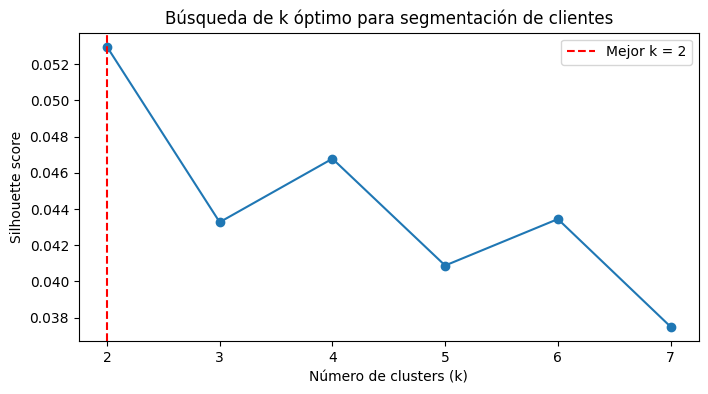

,k,silhouette_score
0,2,0.052968
1,3,0.043274
2,4,0.046781
3,5,0.040880
4,6,0.043446
5,7,0.037499


In [22]:
# Clusterizar clientes sin calcular similitud entre todos los pares
from sklearn.cluster import MiniBatchKMeans
# Buscar n_clusters óptimo con silhouette score
from sklearn.metrics import silhouette_score

k_min = 2
k_max = min(7, X_clientes.shape[0] - 1)
if k_max < k_min:
    raise ValueError("No hay suficientes clientes para evaluar múltiples clusters.")

rango_clusters = range(k_min, k_max + 1)
# Baja este valor si el cálculo tarda demasiado en tu notebook.
tamano_muestra_silhouette = (min(30000, X_clientes.shape[0]))
print(f"Calculando silhouette sobre una muestra de {tamano_muestra_silhouette} clientes")
resultados_silhouette = []

for k in rango_clusters:
    modelo_tmp = MiniBatchKMeans(
        n_clusters=k,
        **parametros_kmeans,
    )
    labels_tmp = modelo_tmp.fit_predict(X_clientes)
    score_tmp = silhouette_score(
        X_clientes,
        labels_tmp,
        metric="cosine",
        sample_size=tamano_muestra_silhouette,
        random_state=42,
    )
    resultados_silhouette.append({
        "k": k,
        "silhouette_score": score_tmp,
    })
    print(f"k={k}: silhouette={score_tmp:.4f}")

resultados_silhouette = pd.DataFrame(resultados_silhouette)
num_clusters = int(
    resultados_silhouette.loc[
        resultados_silhouette["silhouette_score"].idxmax(),
        "k",
    ]
)
print(f"Mejor número de clusters según silhouette: {num_clusters}")

plt.figure(figsize=(8, 4))
plt.plot(
    resultados_silhouette["k"],
    resultados_silhouette["silhouette_score"],
    marker="o",
)
plt.axvline(num_clusters, color="red", linestyle="--", label=f"Mejor k = {num_clusters}")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Búsqueda de k óptimo para segmentación de clientes")
plt.legend()
plt.show()

modelo_clusters = MiniBatchKMeans(
    n_clusters=num_clusters,
    **parametros_kmeans,
)
clusters = modelo_clusters.fit_predict(X_clientes) + 1
resultados_silhouette

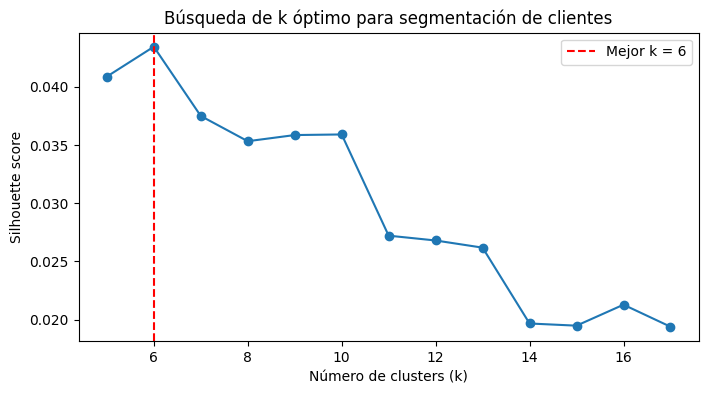

In [45]:
num_clusters = 10
modelo_clusters = MiniBatchKMeans(
    n_clusters=num_clusters,
    **parametros_kmeans,
)
clusters = modelo_clusters.fit_predict(X_clientes) + 1

In [46]:
clusters_finales = clusters

segmentacion_clientes = pd.DataFrame({
    "Cod Cliente": matriz_clientes_skus.index,
    "cluster": clusters_finales,
    "n_skus_distintos": X_clientes.getnnz(axis=1),
})
segmentacion_clientes.head()

,Cod Cliente,cluster,n_skus_distintos
0,235,4,16
1,499,4,14
2,547,10,40
3,665,2,46
4,1012,5,33


In [47]:
# Resumen rápido de la segmentación
resumen_clusters = segmentacion_clientes.groupby("cluster").agg(
    clientes=("Cod Cliente", "count"),
    skus_promedio=("n_skus_distintos", "mean"),
).round(2)
resumen_clusters

,clientes,skus_promedio
cluster,,
1,3073,23.34
2,6245,37.36
3,3723,17.46
4,3462,15.07
5,3833,21.96
6,3473,14.68
7,2835,14.55
8,3682,15.12
9,3485,11.13


# 2. Analisis de Clusters

In [51]:
# Fijamos un cluster y vemos los SKUs más comunes en ese cluster
cluster_elegido = 9
clientes_cluster = segmentacion_clientes[segmentacion_clientes["cluster"] == cluster_elegido]["Cod Cliente"]
skus_cluster = matriz_clientes_skus.loc[clientes_cluster]
skus_comunes = skus_cluster.sum().sort_values(ascending=False).head(20)
#print(f"SKUs más comunes en cluster {cluster_elegido}:\n{skus_comunes}")

if "segmentacion_productos" not in globals():
    path_segmentacion_prods = "datos/segmentacion_productos.xlsx"
    segmentacion_productos = pd.read_excel(path_segmentacion_prods)

cantidad_clientes_cluster = len(clientes_cluster)
nombres_sku = (
    segmentacion_productos[["sku", "descripción"]]
    .drop_duplicates(subset="sku")
    .set_index("sku")["descripción"]
)

tabla_skus_comunes_cluster = (
    skus_cluster.sum()
    .sort_values(ascending=False)
    .head(20)
    .rename_axis("Cod SKU")
    .reset_index(name="conteo_clientes")
)
tabla_skus_comunes_cluster["nombre_sku"] = (
    tabla_skus_comunes_cluster["Cod SKU"].map(nombres_sku).fillna("SKU sin descripcion")
)
tabla_skus_comunes_cluster["porcentaje_clientes_cluster"] = (
    tabla_skus_comunes_cluster["conteo_clientes"] / cantidad_clientes_cluster
)
tabla_skus_comunes_cluster = tabla_skus_comunes_cluster[
    ["Cod SKU", "nombre_sku", "conteo_clientes", "porcentaje_clientes_cluster"]
]
tabla_skus_comunes_cluster

,Cod SKU,nombre_sku,conteo_clientes,porcentaje_clientes_cluster
0,6783,MANTEQUILLA 125 GRS x8 LOS NOGALES,2437,0.699283
1,6770,QUESO GAUDA LAMINADO 1KG.LOS NOGALES,2042,0.585940
2,3313,MORTADELA JAMONADA CENTENARIO LP,1740,0.499283
3,421,PATE TERNERA 8x125 GRS.SJ,1496,0.429268
4,1020,VIENESA TRADICIONAL 20X250 GR SJ,1216,0.348924
5,6777,QUESO LAMINADO GAUDA 250 GR LOS NOGALES,1183,0.339455
6,399,MORTADELA LISA 3 KG SJ,918,0.263415
7,3997,CAJA SNACKIN SALAME LP 10x18 G.,892,0.255954
8,3071,PATE TERNERA 160 Gr.(x10),880,0.252511
9,3239,JAMON CENTENARIO COLONIAL MINI PZA LP,755,0.216643


# 3. Recomendaciones de productos basadas en cluster y segmentación de productos

In [27]:
path_segmentacion_prods = "datos/segmentacion_productos.xlsx"
segmentacion_productos = pd.read_excel(path_segmentacion_prods)
segmentacion_productos.head()

,sku,familia_hana,marca,descripción,kilos,ingresos_m,margen_1_m,margen_2_m,ebitda_m,marca_normalizada,ebitda_pct,margen_pct,segmento_producto
0,20,ARROLLADOS,SAN JORGE,ARROLLADO LOMO CON AJI SJ,304910.749,1485504.407,920326.192396,473199.320903,377154.603983,san jorge,0.253890,0.619538,Héroe
1,27,ARROLLADOS,SAN JORGE,ARROLLADO LOMO SIN AJI SJ,29528.448,143051.886,95038.353662,51746.046069,42538.219324,san jorge,0.297362,0.664363,Héroe
2,30,ARROLLADOS,SAN JORGE,ARROLLADO HUASO CON AJI SJ,168051.512,819658.549,446650.482189,191353.933522,138230.617806,san jorge,0.168644,0.544923,Héroe
3,102,ARROLLADOS,SAN JORGE,ARROLLADO LOMO CON AJI 12x150 GR SJ,47602.650,267161.873,146875.559387,87224.285119,70253.618664,san jorge,0.262963,0.549762,Héroe
4,151,PARRILLEROS,SAN JORGE,CHORIZO 12X250 GR SJ,141443.250,506425.488,302049.550572,110110.200002,75408.309139,san jorge,0.148903,0.596434,Héroe


In [28]:
segmentacion_productos.columns

Index(['sku', 'familia_hana', 'marca', 'descripción', 'kilos', 'ingresos_m',
       'margen_1_m', 'margen_2_m', 'ebitda_m', 'marca_normalizada',
       'ebitda_pct', 'margen_pct', 'segmento_producto'],
      dtype='str')

In [29]:
segmentacion_productos["segmento_producto"].unique()

<StringArray>
['Héroe', 'Seguidor', 'Aprendiz', 'Rebelde', 'Villano']
Length: 5, dtype: str

In [43]:
# ver cliente random de algun cluster
CLUSTER_EJEMPLO = 3
clientes_mismo_cluster = segmentacion_clientes[segmentacion_clientes["cluster"] == CLUSTER_EJEMPLO]["Cod Cliente"]

clientes_mismo_cluster

4           1012
10          1696
14          1965
35          3116
87          5357
          ...   
38530    1238285
38531    1238291
38532    1238306
38533    1238310
38535    1238326
Name: Cod Cliente, Length: 7155, dtype: int64

In [31]:
# Dado un cliente, según su cluster, recomendar SKUs populares (los compra al menos UMBRAL_POPULARIDAD% del cluster) en ese cluster que no haya comprado y que sean del segmento 'Héroe'
CLIENTE_EJEMPLO = 1696
UMBRAL_POPULARIDAD = 0.6 # Porcentaje mínimo de clientes del cluster que deben comprar el SKU para considerarlo popular

def recomendar_skus_para_cliente(cliente_id, verbosity=False):
    cluster_cliente = segmentacion_clientes[segmentacion_clientes["Cod Cliente"] == cliente_id]["cluster"].values[0]
    if verbosity:
        print(f"Cliente {cliente_id} pertenece al cluster {cluster_cliente}")
    clientes_mismo_cluster = segmentacion_clientes[segmentacion_clientes["cluster"] == cluster_cliente]["Cod Cliente"]
    cantidad_clientes_cluster = len(clientes_mismo_cluster)
    if verbosity:
        print(f"Clientes en el mismo cluster ({cluster_cliente}): {cantidad_clientes_cluster}")
    skus_mismo_cluster = matriz_clientes_skus.loc[clientes_mismo_cluster]

    conteo_skus = skus_mismo_cluster.sum().sort_values(ascending=False)
    # Filtrar solo SKUs que compran al menos UMBRAL_POPULARIDAD% de los clientes del cluster
    skus_populares_cluster = conteo_skus[conteo_skus/cantidad_clientes_cluster >= UMBRAL_POPULARIDAD]

    # Traemos las compras del cliente para filtrar solo los SKUs que no ha comprado
    skus_cliente = matriz_clientes_skus.loc[cliente_id]
    # Recomendamos aquellos que el cliente no compra y que son populares en el cluster
    skus_recomendados = skus_populares_cluster[skus_cliente == 0]
    # Filtramos para recomendar sólo los SKUs que son del segmento 'Héroe'
    skus_recomendados = skus_recomendados[skus_recomendados.index.isin(segmentacion_productos[segmentacion_productos["segmento_producto"].isin(["Héroe", "Seguidor"])]["sku"])]

    # Traer nombres de SKUs recomendados
    skus_recomendados = skus_recomendados.to_frame(name="conteo").merge(
        segmentacion_productos[["sku", "descripción"]],
        left_index=True,
        right_on="sku",
    ).drop(columns=["sku"])
    if verbosity:
        print(f"SKUs recomendados para cliente {cliente_id} (cluster {cluster_cliente}):\n{skus_recomendados}")
    # retornamos ids de los SKUs recomendados
    ids_skus_recomendados = skus_recomendados.index.tolist()
    return ids_skus_recomendados

# recomendar_skus_para_cliente(CLIENTE_EJEMPLO, verbosity=True)

In [32]:
# Calcular para cada cliente los skus recomendados y guardarlos como lista en una columna, además de una columan con la cantidad de recomendaciones
segmentacion_clientes["skus_recomendados"] = segmentacion_clientes["Cod Cliente"].apply(lambda x: recomendar_skus_para_cliente(x, verbosity=False))

In [33]:
segmentacion_clientes["cantidad_recomendaciones"] = segmentacion_clientes["skus_recomendados"].apply(lambda x: len(x) if isinstance(x, list) else 0)

In [34]:
segmentacion_clientes.head()

,Cod Cliente,cluster,n_skus_distintos,skus_recomendados,cantidad_recomendaciones
0,235,2,16,[],0
1,499,2,14,[],0
2,547,4,40,[],0
3,665,5,46,[],0
4,1012,3,33,[],0


In [35]:
segmentacion_clientes["cantidad_recomendaciones"].describe()

count    38537.000000
mean         1.256585
std          1.486976
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: cantidad_recomendaciones, dtype: float64

In [36]:
recomendar_skus_para_cliente(547, verbosity=True)

Cliente 547 pertenece al cluster 4
Clientes en el mismo cluster (4): 5230
SKUs recomendados para cliente 547 (cluster 4):
Empty DataFrame
Columns: [conteo, descripción]
Index: []


[]

# 4. Análisis de Clusters resultantes

In [37]:
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes = pd.read_excel(path_clientes, header=1)
clientes.head()

,Zona,Distrito,CodJV,CodSup,CodVend,NombreVendedor,Canal,SubCanal,CodCliente Padre,Cliente Padre,...,MA,MI,JU,VI,SA,Frecuencia,Tratamiento,CodPago,DesPago,Estado
0,SANTIAGO,SANTIAGO CENTRO COSTA,854,854,1084869,ALEXIS PEREZ MUÑOZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,1.0,0,1.0,Cliente,C005,FIRMA 7 DIAS,1
1,SUR 1,RANCAGUA,481,481,482,JUAN FARIAS PEREZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,0.0,0,0.5,Cliente,C000,EFECTIVO - CHEQUE AL DIA,1
2,SUR 2,CONCEPCION SUR,1178566,1178566,1084857,ALEX RIOS CUEVAS,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.5,0.0,0,0.5,Cliente,C017,EFECTIVO,1
3,SUR 1,TALCA,581,581,1160963,RODRIGO AVENDAÑO HERNANDEZ,COBERTURA,COBERTURA,0,-,...,0.0,1.0,0.0,0.0,0,1.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1
4,NORTE 2,VIÑA COSTA,1216438,1216438,1206012,PAULO RUZ BILBAO,COBERTURA,COBERTURA,0,-,...,1.0,0.0,0.0,1.0,0,2.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1


In [38]:
clientes.columns

Index(['Zona', 'Distrito', 'CodJV', 'CodSup', 'CodVend', 'NombreVendedor',
       'Canal', 'SubCanal', 'CodCliente Padre', 'Cliente Padre', 'CodCliente',
       'RazonSocial', 'Direccion', 'Comuna', 'TipoNeg', 'DesTipoNeg', 'Relev',
       'NivPrecio', 'Telefono', 'Correo', 'VtaUlt3M', 'PromUlt3M',
       'Margen3ULTM', 'PromMargen3ULTM', 'CodRuta', 'DesRuta', 'NroSec',
       'RitmoVisita', 'LU', 'MA', 'MI', 'JU', 'VI', 'SA', 'Frecuencia',
       'Tratamiento', 'CodPago', 'DesPago', 'Estado'],
      dtype='str')

In [49]:
# AgregarTipoNeg a segmentacion_clientes
segmentacion_clientes = segmentacion_clientes.merge(clientes[["CodCliente", "DesTipoNeg"]], left_on="Cod Cliente", right_on="CodCliente", how="left")
segmentacion_clientes.drop(columns=["CodCliente"], inplace=True)
segmentacion_clientes.head()

,Cod Cliente,cluster,n_skus_distintos,DesTipoNeg
0,235,4,16,AL - ALMACÉN
1,499,4,14,AL - ALMACÉN
2,547,10,40,AL - ALMACÉN
3,665,2,46,AL - ALMACÉN
4,1012,5,33,AL - ALMACÉN


In [50]:
# Tabla con porcentaje de clientes por TipoNeg en cada cluster
segmentacion_tiponeg = segmentacion_clientes.copy()
segmentacion_tiponeg["DesTipoNeg"] = segmentacion_tiponeg["DesTipoNeg"].fillna("Sin TipoNeg")

clusters_ordenados = sorted(segmentacion_tiponeg["cluster"].dropna().unique())

tabla_tiponeg_cluster = (
    pd.crosstab(
        segmentacion_tiponeg["DesTipoNeg"],
        segmentacion_tiponeg["cluster"],
        normalize="index",
    )
    .reindex(columns=clusters_ordenados, fill_value=0)
    .mul(100)
    .round(1)
)

tabla_tiponeg_cluster.columns = [f"Cluster {int(col)}" for col in tabla_tiponeg_cluster.columns]

cluster_predominante = tabla_tiponeg_cluster.idxmax(axis=1)
porcentaje_predominante = tabla_tiponeg_cluster.max(axis=1)

tabla_tiponeg_cluster["Cluster predominante (%)"] = (
    cluster_predominante
    + " ("
    + porcentaje_predominante.round(1).astype(str)
    + "%)"
)

tabla_tiponeg_cluster

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster predominante (%)
DesTipoNeg,,,,,,,,,,,
AL - ALMACÉN,8.4,14.9,10.8,8.8,9.9,8.3,7.5,9.5,8.1,13.6,Cluster 2 (14.9%)
CA - CARNICERÍA,4.9,8.5,2.5,7.9,6.9,34.3,12.4,7.2,9.0,6.4,Cluster 6 (34.3%)
CF - CAFETERIA,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,Cluster 6 (100.0%)
FI - FIAMBRERÍA,3.8,21.2,4.4,10.0,3.8,13.8,7.5,14.4,16.9,4.4,Cluster 2 (21.2%)
FS - FUENTEDE SODA,0.0,50.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,Cluster 2 (50.0%)
MA - MAYORISTA,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,Cluster 4 (100.0%)
MK - MINIMARKET,3.8,45.5,4.4,1.5,21.6,5.5,7.8,3.4,2.1,4.5,Cluster 2 (45.5%)
PA - PANADERÍA,8.3,29.2,5.1,12.1,6.6,4.8,2.4,12.7,13.4,5.4,Cluster 2 (29.2%)
PZ - PIZZERIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,Cluster 9 (100.0%)


# 5. Otros

In [ ]:
# Cruce: pizzeria ver el porcentaje de compra de los skus del listado
# # Si necesitas clientes similares, calcula solo vecinos cercanos y no toda la matriz cliente-cliente
# from sklearn.neighbors import NearestNeighbors

# k_vecinos = 10
# modelo_vecinos = NearestNeighbors(
#     n_neighbors=k_vecinos + 1,
#     metric="cosine",
#     algorithm="brute",
# )
# modelo_vecinos.fit(X_clientes)

In [42]:
# # Ejemplo: vecinos más parecidos para un cliente
# cliente_objetivo = matriz_clientes_skus.index[0]
# fila_cliente = matriz_clientes_skus.index.get_loc(cliente_objetivo)
# distancias, indices = modelo_vecinos.kneighbors(X_clientes[fila_cliente])

# clientes_similares = pd.DataFrame({
#     "Cod Cliente": matriz_clientes_skus.index[indices[0][1:]],
#     "distancia_coseno": distancias[0][1:],
#     "similitud_coseno": 1 - distancias[0][1:],
# })
# clientes_similares